#### Texture Descriptors

These capture structural, repetitive, or roughness patterns in an image - compact representation of the image’s surface structure.

- Local Binary Patterns
- Gabor filters
- Wavelets
- Fractal dimensions

**Local Binary Patterns**

The LBP Histogram/feature vector summarizes the painting texture distribution, where the x-axis represents LBP patterns for 8 neighbours i.e. 9 bins and y-axis is the normalised frequency of each pattern. If dominating patterns are 1-3 - little to no texture recognised (noisy/no structure), 4-6 - texture is mainly flat or smooth with slight edges, 7-9 good detail in texture features and well structured. Feature vector can be used for texture classification, retrieval, or similarity search. The LBP image is a map of textures at the pixel level, where each pixel is replaced with its LBP code instead of its intensity (0-255). The result is outlined since flat regions, edges and corners get different codes, darker areas - simple textures, brighter areas - complex textures like edges, corners, and details. (Just an output to visualise what LBP is seeing) LBP is rotation-invariant, robust to illumination changes thus only compares relative pixel intensities and provides efficient computation. 

**Gabor filters**

Gabor filters are designed to detect edges, frequencies, and orientations. Uses include texture analysis, face recognition, fingerprint matching and art/style analysis (brushstroke patterns, repetitive motifs). By combining different orientations, scales, and wavelengths, it can capture a multi-resolution texture description of the image. The large mean/variance values e.g. mean=123.086, var=3577.206 indicates orientations and scales where the texture response is strong and those patterns are dominant in the painting. The small values mean that those filters didn’t pick up much structure. Comparing these vectors between paintings tells you how similar their texture patterns are. This method produces a texture profile of the image across multiple orientations and scales. The histogram-like vector of means and variances can be used for clustering paintings by texture style, classification, or even similarity search. Sensitive to orientation and frequency but great for detecting repetitive patterns like brush strokes, fabric, or structural patterns in a painting.

Each filter produces two numbers (mean and var.); for a length 32 vector: 4 orientations × 2 sigmas × 2 lambdas = 16 filters 

**Wavelets**

Wavelet transforms decompose an image into different frequency bands; LL (Low-Low); coarse approximation, low-frequency, coarse version of the image i.e. general intensity and smooth structure, LH (Low-High); horizontal details, vertical edges and horizontal textures, HL (High-Low); vertical details, horizontal edges and vertical textures, HH (High-High); diagonal details, fine diagonal details and noise. Mean and variance per sub-band indicate the average coefficient value (indicates general direction or bias), and how much the coefficients vary (indicates amount of structure or texture energy), respectively.

Structure of the vector:
[LL_mean, LL_var, LH_mean, LH_var, HL_mean, HL_var, HH_mean, HH_var]

In general, its a multi-resolution analysis (due to diff. freq. bands) where features describe texture across scales i.e. low frequency = coarse structure, high frequency = fine details. (Table from chatGPT GPT-5 model)

| Feature     | Expected range             | What low values mean                    | What high values mean                                              |
| ----------- | -------------------------- | --------------------------------------- | ------------------------------------------------------------------ |
| **LL_mean** | ~0 to 255                  | Dark painting overall                   | Bright painting overall                                            |
| **LL_var**  | ~1,000 to 20,000           | Evenly lit / low-contrast (flat tones)  | High contrast / large light-dark areas                             |
| **LH_mean** | ~-5 to +5 (usually near 0) | Symmetry in vertical changes (balanced) | Biased vertical texture (e.g., many brushstrokes one direction)    |
| **LH_var**  | ~100 to 2,000              | Few vertical edges (smooth vertically)  | Strong vertical texture or repetitive vertical strokes             |
| **HL_mean** | ~-5 to +5                  | Balanced horizontally                   | Bias toward one horizontal direction (rare)                        |
| **HL_var**  | ~100 to 2,000              | Few horizontal edges                    | Strong horizontal strokes, horizons, or layering (landscapes)      |
| **HH_mean** | ~-2 to +2                  | Symmetric diagonal patterns             | Bias toward a diagonal structure (e.g., consistent lighting angle) |
| **HH_var**  | ~50 to 1,000               | Smooth with few details                 | Fine brush textures, intricate detail, strong diagonal patterns    |

**Fractal dimensions**

A single number describing the complexity of patterns. Higher = more detailed/chaotic texture, lower = smoother/simpler.Fractal dimension (FD) measures how complex or self-similar a texture is across scales.
It quantifies how much detail appears when zooming in.

FD close to 1 → smoother, line-like patterns, FD close to 2 → rough, highly textured or noise-like, and FD > 2 → rarely in images, would indicate very dense patterns. E.g. canvas strokes, cracks in paintings, or leaf surfaces often fall around 1.7–1.9.

In [1]:
# all necessary imports are listed below
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
import pywt


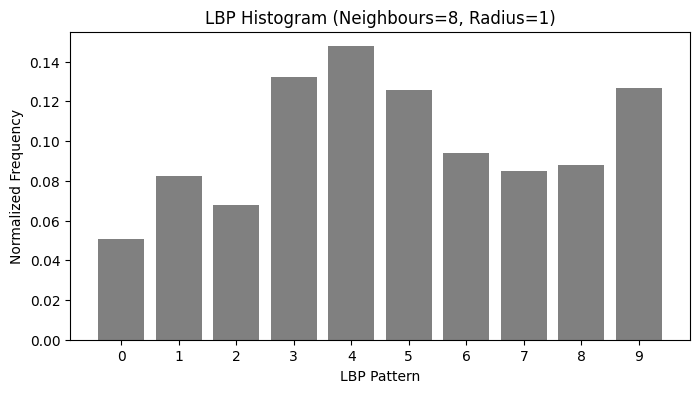

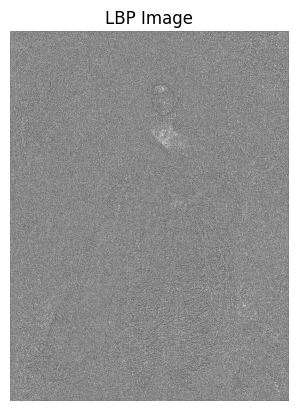

LBP feature vector: 
 [0.0506465  0.08223508 0.06769437 0.13239906 0.14763382 0.12547041
 0.09418671 0.08475012 0.08806397 0.12691995] 

Gabor Features (mean & variance per filter, length=32): 
 [1.583690e+02 4.162546e+03 6.115600e+01 2.098548e+03 2.284000e+01
 1.812595e+03 1.109200e+01 6.288470e+02 2.495170e+02 3.201870e+02
 1.429000e+00 1.073300e+01 1.616110e+02 6.758522e+03 2.152000e+00
 1.988500e+01 1.582290e+02 4.167672e+03 6.117000e+01 2.131704e+03
 2.308900e+01 1.872049e+03 1.301500e+01 7.061670e+02 2.495850e+02
 3.151450e+02 1.383000e+00 9.648000e+00 1.657980e+02 6.079225e+03
 2.147000e+00 1.948600e+01] 

Wavelet Features (mean & variance for LL, LH, HL, HH): 
 [ 1.31152543e+02  8.11271419e+03 -1.11892528e-02  9.96890209e+01
 -4.96434021e-03  9.54981239e+01 -6.27530396e-04  1.92013790e+01] 

Fractal Dimension: 1.4876144952067656 



In [ ]:
# every pixel compared with 8 neighbours in a 1 pixel radius 
def extract_lbp_features(image, neighbours=8, radius=1):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, neighbours, radius, method="uniform")
    
    # histogram of LBP
    hist, _ = np.histogram(lbp.ravel(),
                              bins=np.arange(0, neighbours + 3),
                              range=(0, neighbours + 2))
    hist = hist.astype("float")
    hist /= hist.sum()  
    
    plt.figure(figsize=(8,4))
    plt.bar(range(len(hist)), hist, tick_label=range(len(hist)), color="gray")
    plt.title(f"LBP Histogram (Neighbours={neighbours}, Radius={radius})")
    plt.xlabel("LBP Pattern")
    plt.ylabel("Normalized Frequency")
    plt.show()
    
    return hist, lbp

# plot the histogram, visualize the LBP image and print feature vector
hist, lbp_image = extract_lbp_features(image_rgb)
plt.imshow(lbp_image, cmap="gray")
plt.title("LBP Image")
plt.axis("off")
plt.show()
print ("LBP feature vector: \n", hist, "\n")

# produces a texture profile of the image across multiple orientations and scales
def extract_gabor_features(image, k=31):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    features = []
    
    # define gabor parameters i.e. orientations(theta), scales(sigma), wavelengths(lamda)
    for theta in (0, np.pi/4, np.pi/2, 3*np.pi/4):  
        for sigma in (1, 3):  
            for lamda in (np.pi/4, np.pi/2):  
                kernel = cv2.getGaborKernel((k, k), sigma, theta, lamda, 0.5, 0, ktype=cv2.CV_32F)
                fimg = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
                features.append(round(fimg.mean(), 3))
                features.append(round(fimg.var(), 3))
    return np.array(features)

gabor_features = extract_gabor_features(image_rgb)
print("Gabor Features (mean & variance per filter, length={}): \n".format(len(gabor_features)), gabor_features, "\n")

# decompose image into different frequency bands using discrete wavelet transform with haar wavlet
def extract_wavelet_features(image, wavelet="haar"):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coeffs2 = pywt.dwt2(gray, wavelet)
    LL, (LH, HL, HH) = coeffs2
    
    # mean and variance of each band
    features = [
        LL.mean(), LL.var(),
        LH.mean(), LH.var(),
        HL.mean(), HL.var(),
        HH.mean(), HH.var()
    ]
    return np.array(features)
wavelet_features = extract_wavelet_features(image_rgb, wavelet="haar")
print("Wavelet Features (mean & variance for LL, LH, HL, HH): \n", wavelet_features, "\n")

# value to describe the complexity of a fractal pattern 
def fractal_dimension(image, threshold=128):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # binarize
    _, bw = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    bw = bw // 255
    
    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
                               np.arange(0, Z.shape[1], k), axis=1)
        return len(np.where((S > 0) & (S < k*k))[0])

    # sizes of boxes
    p = min(bw.shape)
    n = 2**np.floor(np.log(p)/np.log(2))
    n = int(n)
    sizes = 2**np.arange(int(np.log(n)/np.log(2)), 1, -1)

    counts = []
    for size in sizes:
        counts.append(boxcount(bw, size))

    # fit log-log
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]  

fd = fractal_dimension(image_rgb)
print("Fractal Dimension:", fd, "\n")